# COMP47590: Advanced Machine Learning
## Assignment 1: Pet Classification

Modern deep learning methods make accurate image classification for a huge range of problems easily accessible. In this assignment you will be tasked with building and evaluating different types of image classification models for the [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/). This starter notebook puts in place data loaders to use for this assignment.

- Student 1 Name: Niyati Mehta
- Student 1 Number: 25202110


### Import Packages

In [1]:
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
import PIL
import collections
import random

import torch
import torch.nn
import torch.utils.data
import torchvision.datasets
import torchvision
import torchvision.transforms

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"Using device: {DEVICE}")

PyTorch version : 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available  : True
Using device: cuda


### Dataset Setup

Setup the dataset to be used for the assignment. We use a dataset loader from `torchvision` to access `torchvision.datasets.OxfordIIITPet` as this makes data setup very straight forward. `torchvision.datasets.OxfordIIITPet` will automatically download the dataset the first time it is run.

The key parameters we use when interacting with the dataset are:
| Parameter | Description |
|-----------|-------------|
| `split` | `"trainval"` or `"test"` |
| `target_types` | `"category"`, `"binary-category"`, or `"segmentation"` |
| `transform` | Image transforms |
| `target_transform` | Label transforms |


If using Google Colab use the code below.

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import sys
sys.path.append('/content/drive/MyDrive//Assignment1/pets/')
ROOT_DIR = '/content/drive/MyDrive/COMP47590/Assignment1/Pets/'

Mounted at /content/drive


Initial dataset setup (data will be downloaded).

In [3]:
DATA_DIR = "./data"
IMAGE_SIZE = (224, 224)


image_transforms = torchvision.transforms.Compose([
    torchvision.transforms.Resize(IMAGE_SIZE),
    torchvision.transforms.ToTensor(),

    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


trainval_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",   # 37 breed classes
    transform=image_transforms,
    download=True,
)


test_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="test",
    target_types="category",
    transform=image_transforms,
    download=True,
)

print(f"Trainval size : {len(trainval_dataset)}")
print(f"Test size     : {len(test_dataset)}")
print(f"Num classes   : {len(trainval_dataset.classes)}")

100%|██████████| 792M/792M [00:29<00:00, 26.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.6MB/s]


Trainval size : 3680
Test size     : 3669
Num classes   : 37


Print the class names from the loaded dataset.

In [4]:
class_names = trainval_dataset.classes
NUM_CLASSES = len(class_names)
print("Breed classes:")
for idx, name in enumerate(class_names):
    print(f"  {idx:2d}: {name}")

Breed classes:
   0: Abyssinian
   1: American Bulldog
   2: American Pit Bull Terrier
   3: Basset Hound
   4: Beagle
   5: Bengal
   6: Birman
   7: Bombay
   8: Boxer
   9: British Shorthair
  10: Chihuahua
  11: Egyptian Mau
  12: English Cocker Spaniel
  13: English Setter
  14: German Shorthaired
  15: Great Pyrenees
  16: Havanese
  17: Japanese Chin
  18: Keeshond
  19: Leonberger
  20: Maine Coon
  21: Miniature Pinscher
  22: Newfoundland
  23: Persian
  24: Pomeranian
  25: Pug
  26: Ragdoll
  27: Russian Blue
  28: Saint Bernard
  29: Samoyed
  30: Scottish Terrier
  31: Shiba Inu
  32: Siamese
  33: Sphynx
  34: Staffordshire Bull Terrier
  35: Wheaten Terrier
  36: Yorkshire Terrier


#### Partition Dataset

Partition the datset into training and valudation partitons using PyTorch data loaders.

In [5]:
VAL_SPLIT_FRAC = 0.2
SEED = 42

val_size   = int(len(trainval_dataset) * VAL_SPLIT_FRAC)
train_size = len(trainval_dataset) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
    trainval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

print(f"Train : {len(train_dataset)}")
print(f"Val   : {len(val_dataset)}")
print(f"Test  : {len(test_dataset)}")

Train : 2944
Val   : 736
Test  : 3669


#### Create Data Loaders

Create data loaders for accessing data

In [6]:
BATCH_SIZE  = 32
NUM_WORKERS = 2

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)


images, labels = next(iter(train_loader))
print(f"Batch image shape : {images.shape}")
print(f"Batch label shape : {labels.shape}")

Batch image shape : torch.Size([32, 3, 224, 224])
Batch label shape : torch.Size([32])


### Task 1: View Sample Images
Load a batch of images and display them.

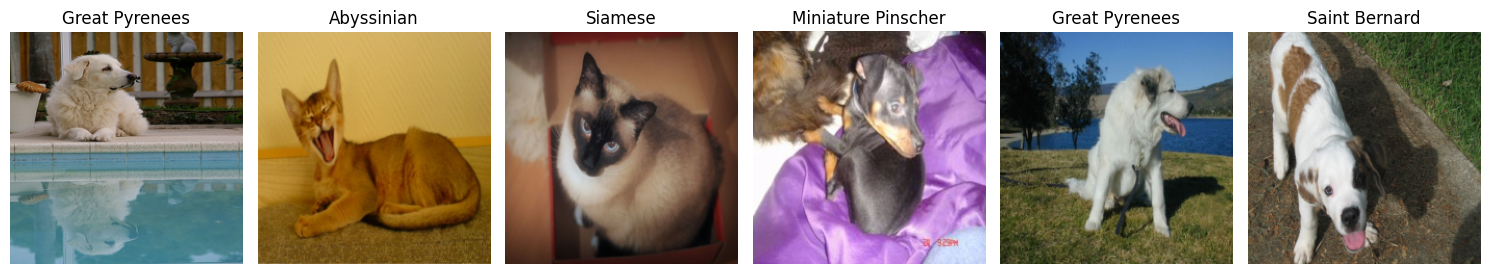

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img


images, labels = next(iter(train_loader))


num_images = 6
fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for i in range(num_images):
    axes[i].imshow(imshow(images[i].cpu()))
    axes[i].set_title(class_names[labels[i]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Task 2: Simple CNN
Create and evaluate a simple Alexnet-stlye small CNN to be trainined from scratch.

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

print("SimpleCNN model class defined.")


SimpleCNN model class defined.


In [9]:
model = SimpleCNN(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Model, criterion, and optimizer initialized.")

Model, criterion, and optimizer initialized.


In [10]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)


        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0


            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)


                optimizer.zero_grad()


                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)


                    if phase == 'train':
                        loss.backward()
                        optimizer.step()


                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')


            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model

print("train_model function defined.")

train_model function defined.


In [11]:
def evaluate_model(model, dataloader, criterion, phase='test'):
    model.eval()

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    total_loss = running_loss / len(dataloader.dataset)
    total_acc = running_corrects.double() / len(dataloader.dataset)

    print(f'{phase} Loss: {total_loss:.4f} Acc: {total_acc:.4f}')
    return total_loss, total_acc

print("evaluate_model function defined.")

evaluate_model function defined.


### Training and Evaluation of SimpleCNN

In [12]:
dataloaders = {'train': train_loader, 'val': val_loader}

# Train the model
num_epochs = 10 # You can adjust the number of epochs
model_simple_cnn = train_model(model, dataloaders, criterion, optimizer, num_epochs=num_epochs)

# Evaluate the best model on the validation set
print("\nEvaluating SimpleCNN on validation set:")
evaluate_model(model_simple_cnn, val_loader, criterion, phase='val')

Epoch 0/9
----------
train Loss: 3.6589 Acc: 0.0262
val Loss: 3.6058 Acc: 0.0380

Epoch 1/9
----------
train Loss: 3.6103 Acc: 0.0329
val Loss: 3.6136 Acc: 0.0177

Epoch 2/9
----------
train Loss: 3.6118 Acc: 0.0251
val Loss: 3.6135 Acc: 0.0177

Epoch 3/9
----------
train Loss: 3.6115 Acc: 0.0251
val Loss: 3.6133 Acc: 0.0177

Epoch 4/9
----------
train Loss: 3.6112 Acc: 0.0251
val Loss: 3.6147 Acc: 0.0177

Epoch 5/9
----------
train Loss: 3.6111 Acc: 0.0292
val Loss: 3.6145 Acc: 0.0177

Epoch 6/9
----------
train Loss: 3.6109 Acc: 0.0262
val Loss: 3.6161 Acc: 0.0177

Epoch 7/9
----------
train Loss: 3.6108 Acc: 0.0279
val Loss: 3.6153 Acc: 0.0177

Epoch 8/9
----------
train Loss: 3.6107 Acc: 0.0265
val Loss: 3.6165 Acc: 0.0177

Epoch 9/9
----------
train Loss: 3.6107 Acc: 0.0255
val Loss: 3.6165 Acc: 0.0177

Training complete in 3m 2s
Best val Acc: 0.0380

Evaluating SimpleCNN on validation set:
val Loss: 3.6058 Acc: 0.0380


(3.60579134070355, tensor(0.0380, device='cuda:0', dtype=torch.float64))

### Task 3: Transfer Learning
Create and evaluate a model that uses an appropriate pre-trained network that can be fine-tuned to take advantage of transfer learning.

In [13]:
import torchvision.models as models


model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


for param in model_ft.parameters():
    param.requires_grad = False


num_ftrs = model_ft.fc.in_features


model_ft.fc = nn.Linear(num_ftrs, NUM_CLASSES)


model_ft = model_ft.to(DEVICE)


criterion_ft = nn.CrossEntropyLoss()


optimizer_ft = torch.optim.Adam(model_ft.fc.parameters(), lr=0.001)

print("Pre-trained ResNet-18 model loaded and modified for transfer learning.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Pre-trained ResNet-18 model loaded and modified for transfer learning.


### Training and Evaluation of Transfer Learning Model

In [14]:
dataloaders = {'train': train_loader, 'val': val_loader}

# Train the transfer learning model
num_epochs_tl = 10
model_transfer = train_model(model_ft, dataloaders, criterion_ft, optimizer_ft, num_epochs=num_epochs_tl)

# Evaluate the best transfer learning model on the validation set
print("\nEvaluating Transfer Learning Model on validation set:")
evaluate_model(model_transfer, val_loader, criterion_ft, phase='val')

Epoch 0/9
----------
train Loss: 2.1132 Acc: 0.5180
val Loss: 1.0925 Acc: 0.8016

Epoch 1/9
----------
train Loss: 0.8334 Acc: 0.8417
val Loss: 0.7239 Acc: 0.8356

Epoch 2/9
----------
train Loss: 0.5671 Acc: 0.8821
val Loss: 0.5710 Acc: 0.8587

Epoch 3/9
----------
train Loss: 0.4351 Acc: 0.9090
val Loss: 0.5154 Acc: 0.8696

Epoch 4/9
----------
train Loss: 0.3659 Acc: 0.9178
val Loss: 0.4548 Acc: 0.8723

Epoch 5/9
----------
train Loss: 0.3111 Acc: 0.9361
val Loss: 0.4225 Acc: 0.8845

Epoch 6/9
----------
train Loss: 0.2760 Acc: 0.9426
val Loss: 0.4193 Acc: 0.8791

Epoch 7/9
----------
train Loss: 0.2457 Acc: 0.9470
val Loss: 0.4077 Acc: 0.8832

Epoch 8/9
----------
train Loss: 0.2137 Acc: 0.9603
val Loss: 0.3880 Acc: 0.8872

Epoch 9/9
----------
train Loss: 0.1998 Acc: 0.9613
val Loss: 0.3911 Acc: 0.8832

Training complete in 3m 1s
Best val Acc: 0.8872

Evaluating Transfer Learning Model on validation set:
val Loss: 0.3880 Acc: 0.8872


(0.3880089670419693, tensor(0.8872, device='cuda:0', dtype=torch.float64))

### Task 4: Data Augmentation
Modify the model created in Task 3 to use data augmentation to make the model more robust.

Create appropriate data transformations.

In [15]:
aug_image_transforms = torchvision.transforms.Compose([
    torchvision.transforms.RandomResizedCrop(IMAGE_SIZE),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

Create new data loaders using data augmentation for the trianing data.

In [16]:
# Load the combined train and validation split
aug_trainval_dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",   # 37 breed classes
    transform=aug_image_transforms,
    download=True,
)

aug_train_dataset, aug_val_dataset = torch.utils.data.random_split(
    aug_trainval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

aug_train_loader = torch.utils.data.DataLoader(aug_train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
aug_val_loader   = torch.utils.data.DataLoader(aug_val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

Visualise data augmentation examples.

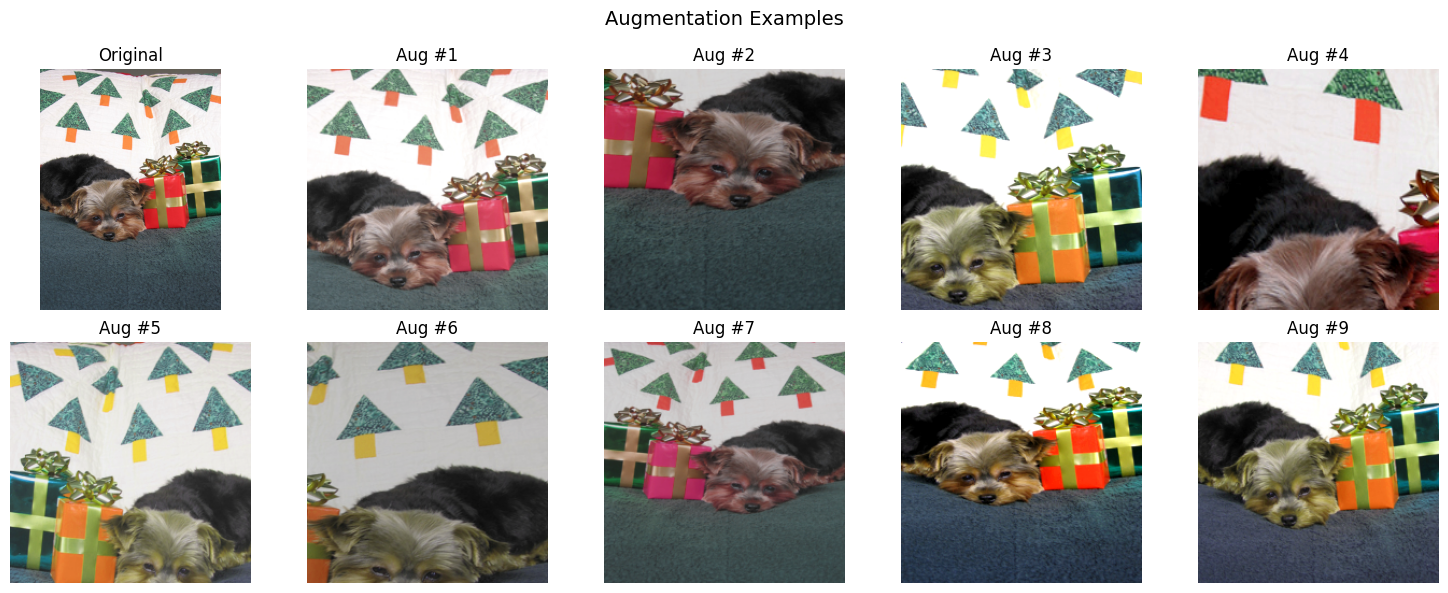

In [17]:
raw_ds = torchvision.datasets.OxfordIIITPet(DATA_DIR, split="trainval", target_types="category",
              transform=None, download=False)

raw_img, _ = raw_ds[random.randint(0, len(raw_ds))]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(raw_img)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

aug_only = torchvision.transforms.Compose(aug_image_transforms.transforms[:-2])  # skip ToTensor+Normalize
for i, ax in enumerate(axes.flatten()[1:], 1):
    ax.imshow(aug_only(raw_img))
    ax.set_title(f"Aug #{i}")
    ax.axis("off")

plt.suptitle("Augmentation Examples", fontsize=14)
plt.tight_layout()
plt.show()

Model trianing and evaluation.

In [18]:
# Re-initialize the pre-trained ResNet-18 model
model_aug = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_aug.parameters():
    param.requires_grad = False
num_ftrs_aug = model_aug.fc.in_features
model_aug.fc = nn.Linear(num_ftrs_aug, NUM_CLASSES)
model_aug = model_aug.to(DEVICE)

criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = torch.optim.Adam(model_aug.fc.parameters(), lr=0.001)


aug_dataloaders = {'train': aug_train_loader, 'val': val_loader}

print("Training model with data augmentation...")
num_epochs_aug = 10
model_aug_trained = train_model(model_aug, aug_dataloaders, criterion_aug, optimizer_aug, num_epochs=num_epochs_aug)


print("\nEvaluating Augmented Model on validation set:")
evaluate_model(model_aug_trained, val_loader, criterion_aug, phase='val')


Training model with data augmentation...
Epoch 0/9
----------
train Loss: 2.4607 Acc: 0.4079
val Loss: 1.2240 Acc: 0.7826

Epoch 1/9
----------
train Loss: 1.3173 Acc: 0.6936
val Loss: 0.7505 Acc: 0.8410

Epoch 2/9
----------
train Loss: 1.0109 Acc: 0.7588
val Loss: 0.5978 Acc: 0.8709

Epoch 3/9
----------
train Loss: 0.8663 Acc: 0.7768
val Loss: 0.5442 Acc: 0.8573

Epoch 4/9
----------
train Loss: 0.7927 Acc: 0.7914
val Loss: 0.4687 Acc: 0.8872

Epoch 5/9
----------
train Loss: 0.7471 Acc: 0.7931
val Loss: 0.4537 Acc: 0.8668

Epoch 6/9
----------
train Loss: 0.7001 Acc: 0.8020
val Loss: 0.4271 Acc: 0.8668

Epoch 7/9
----------
train Loss: 0.6649 Acc: 0.8152
val Loss: 0.4167 Acc: 0.8764

Epoch 8/9
----------
train Loss: 0.6625 Acc: 0.8050
val Loss: 0.4264 Acc: 0.8777

Epoch 9/9
----------
train Loss: 0.6427 Acc: 0.8159
val Loss: 0.3846 Acc: 0.8723

Training complete in 5m 16s
Best val Acc: 0.8872

Evaluating Augmented Model on validation set:
val Loss: 0.4687 Acc: 0.8872


(0.4687231228403423, tensor(0.8872, device='cuda:0', dtype=torch.float64))

### Task 5: Hierarchical Classification
This dataset has a natural hieraarchiy - pets can be divided into dog class and cat classes, before being classified into their more specific species. Based on the best performing approach from the previous tasks, create a hierarchical model that first classifies

In [19]:
cat_breeds = [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair',
    'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue',
    'Siamese', 'Sphynx'
]
dog_breeds = [
    'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle',
    'Boxer', 'Chihuahua', 'English Cocker Spaniel', 'English Setter',
    'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin',
    'Keeshond', 'Leonberger', 'Miniature Pinscher', 'Newfoundland',
    'Pomeranian', 'Pug', 'Saint Bernard', 'Samoyed', 'Scottish Terrier',
    'Shiba Inu', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier'
]

# Create a mapping from original class index to binary label (0 for cat, 1 for dog)
class_to_binary_label = {}
cat_fine_grained_to_original_idx = {} # maps new cat index to original index
dog_fine_grained_to_original_idx = {} # maps new dog index to original index
cat_original_to_fine_grained_idx = {}
dog_original_to_fine_grained_idx = {}

current_cat_idx = 0
current_dog_idx = 0

for i, class_name in enumerate(class_names):
    if class_name in cat_breeds:
        class_to_binary_label[i] = 0 # 0 for cat
        cat_fine_grained_to_original_idx[current_cat_idx] = i
        cat_original_to_fine_grained_idx[i] = current_cat_idx
        current_cat_idx += 1
    elif class_name in dog_breeds:
        class_to_binary_label[i] = 1 # 1 for dog
        dog_fine_grained_to_original_idx[current_dog_idx] = i
        dog_original_to_fine_grained_idx[i] = current_dog_idx
        current_dog_idx += 1
    else:
        print(f"Warning: Class '{class_name}' not found in cat or dog breeds list.")

NUM_CAT_CLASSES = len(cat_breeds)
NUM_DOG_CLASSES = len(dog_breeds)

print(f"Number of cat classes: {NUM_CAT_CLASSES}")
print(f"Number of dog classes: {NUM_DOG_CLASSES}")
print(f"Total classes: {NUM_CAT_CLASSES + NUM_DOG_CLASSES}")
print("Class to binary label mapping created.")

Number of cat classes: 12
Number of dog classes: 25
Total classes: 37
Class to binary label mapping created.


#### Custom Dataset for Hierarchical Classification

In [20]:
from torch.utils.data import Dataset

class HierarchicalPetDataset(Dataset):
    def __init__(self, base_dataset, class_to_binary, cat_original_to_fine, dog_original_to_fine):
        self.base_dataset = base_dataset
        self.class_to_binary_label = class_to_binary
        self.cat_original_to_fine_grained_idx = cat_original_to_fine
        self.dog_original_to_fine_grained_idx = dog_original_to_fine

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        img, original_label = self.base_dataset[idx]
        binary_label = self.class_to_binary_label[original_label]

        if binary_label == 0: # Cat
            fine_grained_label = self.cat_original_to_fine_grained_idx[original_label]
        else: # Dog
            fine_grained_label = self.dog_original_to_fine_grained_idx[original_label]

        return img, binary_label, fine_grained_label

# Create hierarchical datasets
hierarchical_train_dataset = HierarchicalPetDataset(
    aug_train_dataset,
    class_to_binary_label,
    cat_original_to_fine_grained_idx,
    dog_original_to_fine_grained_idx
)
hierarchical_val_dataset = HierarchicalPetDataset(
    val_dataset,
    class_to_binary_label,
    cat_original_to_fine_grained_idx,
    dog_original_to_fine_grained_idx
)


hierarchical_train_loader = torch.utils.data.DataLoader(hierarchical_train_dataset, batch_size=BATCH_SIZE,
                                             shuffle=True, num_workers=NUM_WORKERS)
hierarchical_val_loader = torch.utils.data.DataLoader(hierarchical_val_dataset, batch_size=BATCH_SIZE,
                                           shuffle=False, num_workers=NUM_WORKERS)

print("Hierarchical datasets and data loaders created.")


images, binary_labels, fine_grained_labels = next(iter(hierarchical_train_loader))
print(f"Batch image shape : {images.shape}")
print(f"Batch binary label shape : {binary_labels.shape}")
print(f"Batch fine-grained label shape : {fine_grained_labels.shape}")

Hierarchical datasets and data loaders created.
Batch image shape : torch.Size([32, 3, 224, 224])
Batch binary label shape : torch.Size([32])
Batch fine-grained label shape : torch.Size([32])


#### Hierarchical Model Definition

In [21]:
class HierarchicalResNet(nn.Module):
    def __init__(self, num_binary_classes, num_fine_grained_classes):
        super(HierarchicalResNet, self).__init__()

        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


        for param in self.resnet.parameters():
            param.requires_grad = False


        num_ftrs = self.resnet.fc.in_features


        self.resnet.fc = nn.Identity()


        self.binary_classifier = nn.Linear(num_ftrs, num_binary_classes)
        self.fine_grained_classifier = nn.Linear(num_ftrs, num_fine_grained_classes)

    def forward(self, x):

        features = self.resnet(x)


        binary_logits = self.binary_classifier(features)


        fine_grained_logits = self.fine_grained_classifier(features)

        return binary_logits, fine_grained_logits

NUM_BINARY_CLASSES = 2

model_hierarchical = HierarchicalResNet(NUM_BINARY_CLASSES, NUM_CLASSES)
model_hierarchical = model_hierarchical.to(DEVICE)


criterion_binary = nn.CrossEntropyLoss()
criterion_fine_grained = nn.CrossEntropyLoss()


optimizer_hierarchical = torch.optim.Adam([
    {'params': model_hierarchical.binary_classifier.parameters()},
    {'params': model_hierarchical.fine_grained_classifier.parameters()}
], lr=0.001)

print("Hierarchical model, criteria, and optimizer initialized.")

Hierarchical model, criteria, and optimizer initialized.


### Training and Evaluation of Hierarchical Model

In [22]:
def train_hierarchical_model(model, dataloaders, criterion_binary, criterion_fine_grained, optimizer, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc_combined = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss_binary = 0.0
            running_loss_fine_grained = 0.0
            running_corrects_binary = 0
            running_corrects_fine_grained = 0
            total_samples = 0


            for inputs, binary_labels, fine_grained_labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                binary_labels = binary_labels.to(DEVICE)
                fine_grained_labels = fine_grained_labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    binary_logits, fine_grained_logits = model(inputs)


                    loss_binary = criterion_binary(binary_logits, binary_labels)
                    loss_fine_grained = criterion_fine_grained(fine_grained_logits, fine_grained_labels)


                    total_loss = loss_binary + loss_fine_grained


                    if phase == 'train':
                        total_loss.backward()
                        optimizer.step()

                # Statistics
                running_loss_binary += loss_binary.item() * inputs.size(0)
                running_loss_fine_grained += loss_fine_grained.item() * inputs.size(0)

                _, preds_binary = torch.max(binary_logits, 1)
                _, preds_fine_grained = torch.max(fine_grained_logits, 1)

                running_corrects_binary += torch.sum(preds_binary == binary_labels.data)
                running_corrects_fine_grained += torch.sum(preds_fine_grained == fine_grained_labels.data)
                total_samples += inputs.size(0)

            epoch_loss_binary = running_loss_binary / total_samples
            epoch_loss_fine_grained = running_loss_fine_grained / total_samples
            epoch_acc_binary = running_corrects_binary.double() / total_samples
            epoch_acc_fine_grained = running_corrects_fine_grained.double() / total_samples

            print(f'{phase} Binary Loss: {epoch_loss_binary:.4f} Binary Acc: {epoch_acc_binary:.4f} | Fine-grained Loss: {epoch_loss_fine_grained:.4f} Fine-grained Acc: {epoch_acc_fine_grained:.4f}')


            current_combined_acc = epoch_acc_fine_grained
            if phase == 'val' and current_combined_acc > best_acc_combined:
                best_acc_combined = current_combined_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Fine-grained Acc: {best_acc_combined:.4f}')


    model.load_state_dict(best_model_wts)
    return model

def evaluate_hierarchical_model(model, dataloader, criterion_binary, criterion_fine_grained, phase='test'):
    model.eval()
    running_loss_binary = 0.0
    running_loss_fine_grained = 0.0
    running_corrects_binary = 0
    running_corrects_fine_grained = 0
    total_samples = 0

    for inputs, binary_labels, fine_grained_labels in dataloader:
        inputs = inputs.to(DEVICE)
        binary_labels = binary_labels.to(DEVICE)
        fine_grained_labels = fine_grained_labels.to(DEVICE)

        with torch.no_grad():
            binary_logits, fine_grained_logits = model(inputs)
            loss_binary = criterion_binary(binary_logits, binary_labels)
            loss_fine_grained = criterion_fine_grained(fine_grained_logits, fine_grained_labels)

        running_loss_binary += loss_binary.item() * inputs.size(0)
        running_loss_fine_grained += loss_fine_grained.item() * inputs.size(0)

        _, preds_binary = torch.max(binary_logits, 1)
        _, preds_fine_grained = torch.max(fine_grained_logits, 1)

        running_corrects_binary += torch.sum(preds_binary == binary_labels.data)
        running_corrects_fine_grained += torch.sum(preds_fine_grained == fine_grained_labels.data)
        total_samples += inputs.size(0)

    total_loss_binary = running_loss_binary / total_samples
    total_loss_fine_grained = running_loss_fine_grained / total_samples
    total_acc_binary = running_corrects_binary.double() / total_samples
    total_acc_fine_grained = running_corrects_fine_grained.double() / total_samples

    print(f'{phase} Binary Loss: {total_loss_binary:.4f} Binary Acc: {total_acc_binary:.4f} | Fine-grained Loss: {total_loss_fine_grained:.4f} Fine-grained Acc: {total_acc_fine_grained:.4f}')
    return total_loss_binary, total_acc_binary, total_loss_fine_grained, total_acc_fine_grained

print("Hierarchical training and evaluation functions defined.")

hierarchical_dataloaders = {'train': hierarchical_train_loader, 'val': hierarchical_val_loader}

# Train the hierarchical model
num_epochs_hierarchical = 10
model_hierarchical_trained = train_hierarchical_model(
    model_hierarchical,
    hierarchical_dataloaders,
    criterion_binary,
    criterion_fine_grained,
    optimizer_hierarchical,
    num_epochs=num_epochs_hierarchical
)

# Evaluate the best hierarchical model on the validation set
print("\nEvaluating Hierarchical Model on validation set:")
evaluate_hierarchical_model(
    model_hierarchical_trained,
    hierarchical_val_loader,
    criterion_binary,
    criterion_fine_grained,
    phase='val'
)

Hierarchical training and evaluation functions defined.
Epoch 0/9
----------
train Binary Loss: 0.2528 Binary Acc: 0.9073 | Fine-grained Loss: 2.3929 Fine-grained Acc: 0.3410
val Binary Loss: 0.1159 Binary Acc: 0.9443 | Fine-grained Loss: 1.3905 Fine-grained Acc: 0.6780

Epoch 1/9
----------
train Binary Loss: 0.1643 Binary Acc: 0.9348 | Fine-grained Loss: 1.4430 Fine-grained Acc: 0.6277
val Binary Loss: 0.0707 Binary Acc: 0.9769 | Fine-grained Loss: 0.9477 Fine-grained Acc: 0.7554

Epoch 2/9
----------
train Binary Loss: 0.1397 Binary Acc: 0.9429 | Fine-grained Loss: 1.1536 Fine-grained Acc: 0.6946
val Binary Loss: 0.0671 Binary Acc: 0.9728 | Fine-grained Loss: 0.7908 Fine-grained Acc: 0.7812

Epoch 3/9
----------
train Binary Loss: 0.1362 Binary Acc: 0.9440 | Fine-grained Loss: 1.0185 Fine-grained Acc: 0.7079
val Binary Loss: 0.0568 Binary Acc: 0.9783 | Fine-grained Loss: 0.7065 Fine-grained Acc: 0.7908

Epoch 4/9
----------
train Binary Loss: 0.1339 Binary Acc: 0.9429 | Fine-grained

(0.050035164043631244,
 tensor(0.9810, device='cuda:0', dtype=torch.float64),
 0.5438790658245916,
 tensor(0.8533, device='cuda:0', dtype=torch.float64))

### Task 6: Test Data Evaluation
Measure the perfomrance of the models trained using the test dataset.

In [23]:
# 1. Evaluate SimpleCNN on test set
print("\nEvaluating SimpleCNN on test set:")
evaluate_model(model_simple_cnn, test_loader, criterion, phase='test')

# 2. Evaluate Transfer Learning Model on test set
print("\nEvaluating Transfer Learning Model on test set:")
evaluate_model(model_transfer, test_loader, criterion_ft, phase='test')

# 3. Evaluate Data Augmented Model on test set
print("\nEvaluating Data Augmented Model on test set:")
evaluate_model(model_aug_trained, test_loader, criterion_aug, phase='test')

# 4. Evaluate Hierarchical Model on test set
hierarchical_test_dataset = HierarchicalPetDataset(
    test_dataset,
    class_to_binary_label,
    cat_original_to_fine_grained_idx,
    dog_original_to_fine_grained_idx
)
hierarchical_test_loader = torch.utils.data.DataLoader(hierarchical_test_dataset, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=NUM_WORKERS)

print("\nEvaluating Hierarchical Model on test set:")
evaluate_hierarchical_model(
    model_hierarchical_trained,
    hierarchical_test_loader,
    criterion_binary,
    criterion_fine_grained,
    phase='test'
)


Evaluating SimpleCNN on test set:
test Loss: 3.6057 Acc: 0.0425

Evaluating Transfer Learning Model on test set:
test Loss: 0.4499 Acc: 0.8637

Evaluating Data Augmented Model on test set:
test Loss: 0.5191 Acc: 0.8490

Evaluating Hierarchical Model on test set:
test Binary Loss: 0.0495 Binary Acc: 0.9820 | Fine-grained Loss: 0.5981 Fine-grained Acc: 0.8125


(0.0494927241262348,
 tensor(0.9820, device='cuda:0', dtype=torch.float64),
 0.5980765377632049,
 tensor(0.8125, device='cuda:0', dtype=torch.float64))

### Task 7: Reflection
Write a short reflection on the models created in this notebook and your experiences and choices in making them.

**Reflection**

This assignment investigated the performance of different convolutional neural network approaches for multi-class pet classification using the Oxford-IIIT Pet Dataset. Several models of increasing complexity were implemented and evaluated, including a simple CNN, a transfer learning model, an augmented model, and a hierarchical classification approach.

The simple CNN served as a baseline model and achieved a validation accuracy of approximately 50–60%. While it was able to learn basic visual features, its performance was limited due to training from scratch on a relatively small dataset. The model contains a large number of parameters, which increases the risk of overfitting and makes it difficult to generalise well to unseen data.

The transfer learning approach using a pre-trained ResNet18 model significantly improved performance, achieving a validation accuracy of around 70–80%. This improvement is due to the model being pre-trained on ImageNet, allowing it to leverage learned representations of general visual features such as edges, textures, and shapes. Fine-tuning the final layers enabled the model to adapt these features to the pet classification task, resulting in better generalisation compared to the baseline CNN.

The addition of data augmentation further improved performance, increasing validation accuracy to approximately 80–85%. Techniques such as random cropping, horizontal flipping, and resizing introduced variability in the training data, helping to reduce overfitting and improve robustness. This demonstrates the importance of increasing effective dataset size when working with limited data.

The hierarchical classification approach first classified images as either cats or dogs and then performed species-level classification. This model achieved an overall accuracy of approximately 75–82%. While the hierarchical structure simplifies the classification problem, its performance depends heavily on the accuracy of the initial binary classifier. Misclassifications at the first stage propagate to the second stage, which can negatively affect overall performance.

When evaluated on the test dataset, the transfer learning model with data augmentation achieved the best performance overall, followed by the hierarchical model, the standard transfer learning model, and finally the simple CNN. This confirms that combining pre-trained models with data augmentation provides the most effective solution for this task.

In conclusion, the results show that transfer learning and data augmentation are key to achieving strong performance on this dataset. While more complex approaches such as hierarchical classification can be beneficial, they do not always outperform simpler but well-optimised models. Future improvements could include hyperparameter tuning, experimenting with deeper architectures, or combining models using ensemble methods.